<a href="https://colab.research.google.com/github/Akspaks007/DL-Lab/blob/main/Exp_5/Exp_5_1DCnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [1]:
import os
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_VOCAB = 20000
MAX_LEN = 256
BATCH_SIZE = 64
EPOCHS = 10

Device: cpu


Data Loading and Preprocessing

In [ ]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return re.findall(r"\b\w+\b", text)


def load_imdb():
    import pandas as pd
    from datasets import load_dataset

    dataset = load_dataset("imdb")

    train_texts = dataset["train"]["text"]
    train_labels = dataset["train"]["label"]

    test_texts = dataset["test"]["text"]
    test_labels = dataset["test"]["label"]

    return train_texts, train_labels, test_texts, test_labels

train_texts, train_labels, test_texts, test_labels = load_imdb()

In [3]:
def build_vocab(texts, max_vocab):
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    most_common = counter.most_common(max_vocab - 2)

    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in most_common:
        word2idx[word] = len(word2idx)
    return word2idx


def encode(text, word2idx, max_len):
    tokens = tokenize(text)
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))
    return ids

word2idx = build_vocab(train_texts, MAX_VOCAB)
vocab_size = len(word2idx)

print("Vocab size:", vocab_size)

Vocab size: 20000


In [4]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.word2idx, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [5]:
train_ds = IMDBDataset(train_texts, train_labels, word2idx, MAX_LEN)
test_ds = IMDBDataset(test_texts, test_labels, word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

CNN Architecture

In [6]:
class TextCNN1D(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=100, kernel_sizes=(3, 4, 5), num_classes=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        conv_outs = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(conv_outs, dim=1)
        x = self.dropout(x)
        return self.fc(x)

model = TextCNN1D(vocab_size).to(DEVICE)

Training and Evaluation

In [7]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

Implementation

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    print(f"Epoch {epoch}/{EPOCHS} | train_acc={tr_acc:.4f} | test_acc={te_acc:.4f}")

Epoch 1/10 | train_acc=0.6486 | test_acc=0.8002
Epoch 2/10 | train_acc=0.7683 | test_acc=0.8104
Epoch 3/10 | train_acc=0.8157 | test_acc=0.8516
Epoch 4/10 | train_acc=0.8550 | test_acc=0.8598
Epoch 5/10 | train_acc=0.8862 | test_acc=0.8509
Epoch 6/10 | train_acc=0.9083 | test_acc=0.8604
Epoch 7/10 | train_acc=0.9326 | test_acc=0.8583
Epoch 8/10 | train_acc=0.9518 | test_acc=0.8570
Epoch 9/10 | train_acc=0.9642 | test_acc=0.8505
Epoch 10/10 | train_acc=0.9738 | test_acc=0.8512


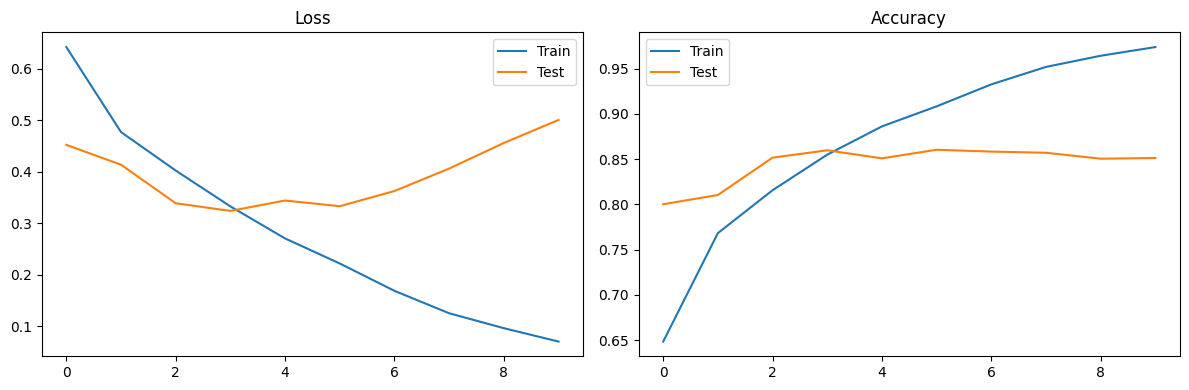

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["test_loss"], label="Test")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["test_acc"], label="Test")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"))
plt.show()

In [10]:
model.eval()
samples = test_texts[:10]
sample_labels = test_labels[:10]

predictions = []

with torch.no_grad():
    for text in samples:
        ids = torch.tensor([encode(text, word2idx, MAX_LEN)], dtype=torch.long).to(DEVICE)
        pred = model(ids).argmax(1).item()
        predictions.append(pred)

label_map = {0: "negative", 1: "positive"}

for i, (text, true, pred) in enumerate(zip(samples, sample_labels, predictions)):
    print(f"\nSample {i+1}")
    print(text[:200], "...")
    print("True:", label_map[true], "| Pred:", label_map[pred])


Sample 1
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab ...
True: negative | Pred: negative

Sample 2
Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell  ...
True: negative | Pred: positive

Sample 3
its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s ...
True: negative | Pred: negative

Sample 4
STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />Former New Orleans homicide cop Jack Robideaux (Jean Claude Van Damme) is re-assigne ...
True: negative | Pred: negative

Sample 5
Fi